# 06 – Country-Level Cargo Shipping Network

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Port-level networks capture fine-grained structure, but a **country-level network** reveals macro-scale trade patterns:
which nations dominate global cargo flows, how tightly interconnected different world regions are,
and how the geopolitical structure of shipping changed from 2015 to 2025.

We aggregate the port-to-port edge lists by extracting the **3-letter country prefix** from each GFW port ID
(e.g. `chn-shanghai` → `CHN`, `nld-rotterdam` → `NLD`) and summing all voyage counts between each country pair.

### Sections
1. Build Country-Level Networks
2. Basic Statistics
3. Country Strength Distribution
4. Top Countries by Strength and Degree
5. Temporal Comparison: 2015 vs 2025
6. Country Flow Balance (Net Importer / Exporter)
7. Community Structure at Country Level
8. Country Centrality: PageRank and Betweenness
9. Country-Level Gini & Trade Concentration
10. Summary Table


In [ ]:
# Importing necessary libraries
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict

# Defining the path for saving all plots and figures generated for analysis in the below code cells
FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True) # Making the directory for saving the plots and figures if it doesn't already exist

# Updating the params of the matplotlib library for better plots and visualizations
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Defining the ISO 3166-1 alpha-3 → country name (subset covering GFW codes)
ISO3_NAME = {
    'chn': 'China',         'usa': 'USA',           'nld': 'Netherlands',
    'deu': 'Germany',       'bel': 'Belgium',        'sgp': 'Singapore',
    'kor': 'South Korea',   'jpn': 'Japan',          'gbr': 'UK',
    'esp': 'Spain',         'mys': 'Malaysia',       'are': 'UAE',
    'tur': 'Turkey',        'grc': 'Greece',         'ita': 'Italy',
    'fra': 'France',        'dnk': 'Denmark',        'swe': 'Sweden',
    'nor': 'Norway',        'fin': 'Finland',        'pol': 'Poland',
    'rus': 'Russia',        'bra': 'Brazil',         'aus': 'Australia',
    'ind': 'India',         'lka': 'Sri Lanka',      'twn': 'Taiwan',
    'hkg': 'Hong Kong',     'phl': 'Philippines',    'idn': 'Indonesia',
    'tha': 'Thailand',      'vnm': 'Vietnam',        'pak': 'Pakistan',
    'bgd': 'Bangladesh',    'sau': 'Saudi Arabia',   'kwt': 'Kuwait',
    'bhr': 'Bahrain',       'omn': 'Oman',           'irn': 'Iran',
    'irq': 'Iraq',          'egy': 'Egypt',          'mar': 'Morocco',
    'nga': 'Nigeria',       'zaf': 'South Africa',   'mex': 'Mexico',
    'arg': 'Argentina',     'chl': 'Chile',          'col': 'Colombia',
    'per': 'Peru',          'can': 'Canada',         'prt': 'Portugal',
    'mlt': 'Malta',         'cyp': 'Cyprus',         'gib': 'Gibraltar',
    'pan': 'Panama',        'mhl': 'Marshall Is.',   'plw': 'Palau',
    'vut': 'Vanuatu',       'lbr': 'Liberia',        'tto': 'Trinidad',
    'jam': 'Jamaica',       'bhs': 'Bahamas',        'cub': 'Cuba',
    'dom': 'Dominican Rep.','hti': 'Haiti',          'pri': 'Puerto Rico',
    'ukr': 'Ukraine',       'ltu': 'Lithuania',      'lva': 'Latvia',
    'est': 'Estonia',       'hrv': 'Croatia',        'svn': 'Slovenia',
    'mne': 'Montenegro',    'alb': 'Albania',        'mkd': 'North Macedonia',
    'srb': 'Serbia',        'bih': 'Bosnia',         'rou': 'Romania',
    'bgr': 'Bulgaria',      'geo': 'Georgia',        'aze': 'Azerbaijan',
    'kaz': 'Kazakhstan',    'tkm': 'Turkmenistan',   'uzb': 'Uzbekistan',
    'nzl': 'New Zealand',   'png': 'Papua N.G.',     'fji': 'Fiji',
    'nzl': 'New Zealand',   'moz': 'Mozambique',     'tza': 'Tanzania',
    'ken': 'Kenya',         'dji': 'Djibouti',       'som': 'Somalia',
    'yem': 'Yemen',         'lbn': 'Lebanon',        'isr': 'Israel',
    'jor': 'Jordan',        'syr': 'Syria',          'lby': 'Libya',
    'tun': 'Tunisia',       'dza': 'Algeria',        'ago': 'Angola',
    'gnq': 'Eq. Guinea',    'cmr': 'Cameroon',       'gha': 'Ghana',
    'civ': 'Ivory Coast',   'sen': 'Senegal',        'mrt': 'Mauritania',
    'cpv': 'Cape Verde',    'gnb': 'Guinea-Bissau',  'gin': 'Guinea',
    'sle': 'Sierra Leone',  'lbr': 'Liberia',        'tgo': 'Togo',
    'ben': 'Benin',         'mus': 'Mauritius',      'mdg': 'Madagascar',
    'reu': 'Réunion',       'com': 'Comoros',        'syc': 'Seychelles',
    'mmr': 'Myanmar',       'khm': 'Cambodia',       'brn': 'Brunei',
    'mco': 'Monaco',        'pyt': 'France-S',
}

# Defining a function to extract the country code from the given port id
def country_code(port_id):
    """Extract the 3-letter country code from a GFW port ID (e.g. 'chn-shanghai' → 'chn')."""
    return port_id.split('-')[0].lower() if '-' in str(port_id) else str(port_id).lower()[:3]

# Defining a helper function to extract the find the country name of the given country code acc. to tthe above defined country code -> country name dict mapping
def country_name(code):
    return ISO3_NAME.get(code.lower(), code.upper())

print('Helpers loaded.')


Helpers loaded.


## 1. Build Country-Level Networks

We parse the country code from every port ID and aggregate:
- **Directed weighted graph** `Gc_d` — edge (A→B) weight = total voyages from any A-port to any B-port
- **Undirected weighted graph** `Gc_u` — edge weight = sum of both directions
- **Self-loops excluded** (intra-country voyages removed)


In [ ]:
# Defining the paths where the edge lists are present as csv files for both years
DATA_2015 = '../EdgeList/shipping_network_2015.csv'
DATA_2025 = '../EdgeList/shipping_network_2025.csv'

# Defining a function for constructing the country network from the GCSN edge list data path
def build_country_networks(path):

    # Reading the GCSN data from the given csv file path into a pandas DataFrame
    df = pd.read_csv(path)

    # Creating a new col of the dataframe using the above defined helper function of extarcting country code from the given port id for each row
    df['src_c'] = df['source'].apply(country_code)
    df['tgt_c'] = df['target'].apply(country_code)

    # Aggregating the edge weights per country pair (and dropping self-loops)
    df_agg = (df[df['src_c'] != df['tgt_c']]
                .groupby(['src_c', 'tgt_c'], as_index=False)['weight'].sum())

    # Initialising an empty directed graph object
    Gd = nx.DiGraph()

    # Creating the directed graph for the country network with appropriate weights
    for _, row in df_agg.iterrows():
        Gd.add_edge(row['src_c'], row['tgt_c'], weight=int(row['weight']))

    # Initialising an empty undirected graph object
    Gu = nx.Graph()

    # Creating the undirected weighted graph for the country network as well from the above created directed weighted network
    for u, v, d in Gd.edges(data=True):
        if Gu.has_edge(u, v):
            Gu[u][v]['weight'] += d['weight']
        else:
            w_rev = Gd[v][u]['weight'] if Gd.has_edge(v, u) else 0
            Gu.add_edge(u, v, weight=d['weight'] + w_rev)

    return Gd, Gu, df_agg # Returning the aggregated dataframe, and newly constructed weighted directed and undirected graphs for the country network

# Building the country networks from both years' data
Gc_d_2015, Gc_u_2015, df_c_2015 = build_country_networks(DATA_2015)
Gc_d_2025, Gc_u_2025, df_c_2025 = build_country_networks(DATA_2025)

# Iterating over the above obtained country networks and their respective year info
for year, Gd, Gu in [('2015', Gc_d_2015, Gc_u_2015), ('2025', Gc_d_2025, Gc_u_2025)]:

    # Printing basic statistics for each constructed network
    print(f'\n{year} country-level network:')
    print(f'  Countries (nodes) : {Gd.number_of_nodes()}')
    print(f'  Directed edges    : {Gd.number_of_edges()}')
    print(f'  Undirected edges  : {Gu.number_of_edges()}')
    print(f'  Density           : {nx.density(Gu):.4f}')
    print(f'  Total voyages     : {sum(d["weight"] for _,_,d in Gd.edges(data=True)):,}')


2015 country-level network:
  Countries (nodes) : 201
  Directed edges    : 7417
  Undirected edges  : 4591
  Density           : 0.2284
  Total voyages     : 750,821

2025 country-level network:
  Countries (nodes) : 203
  Directed edges    : 7431
  Undirected edges  : 4611
  Density           : 0.2249
  Total voyages     : 730,046


## 2. Basic Statistics


In [ ]:
# Defining a functin to compute a compact set of country-level summary statistics
def country_stats(Gd, Gu, year):
    N  = Gd.number_of_nodes() # Calculating the number of nodes in the given directed graph
    E  = Gd.number_of_edges() # Calculating the number of directed edges in the given directed graph

    # Calculating the mean (undirected) degree and mean strength (weighted degree) for the given graph
    k_mean = np.mean([d for _, d in Gu.degree()])
    s_mean = np.mean([d for _, d in Gu.degree(weight='weight')])

    # Finding out the largest connected component (GCC) and its share (fraction) of nodes
    gcc = max(nx.connected_components(Gu), key=len)
    gcc_pct = len(gcc) / N * 100

    # Calculating the reciprocity of the directed country network (fraction of mutual directed edges or bidirectional edges)
    recip = nx.reciprocity(Gd)

    # Calculating the global clustering coefficient of the undirected weighted country network
    C = nx.average_clustering(Gu)

    # Printing the summary in a nicely formatted human-readable format
    print(f'\n{year} country-level summary:')
    print(f'  N countries     : {N}')
    print(f'  Directed edges  : {E}')
    print(f'  Mean degree     : {k_mean:.2f}')
    print(f'  Mean strength   : {s_mean:,.0f}')
    print(f'  GCC size        : {len(gcc)} ({gcc_pct:.1f}%)')
    print(f'  Reciprocity     : {recip:.4f}')
    print(f'  Clustering C    : {C:.4f}')

    # Returning a dict so these values can be used later
    return {'year': year, 'N': N, 'E': E, 'k_mean': k_mean,
            's_mean': s_mean, 'gcc_pct': gcc_pct, 'reciprocity': recip, 'clustering': C}

# Computing and storing the summary stats for both years
stats_15 = country_stats(Gc_d_2015, Gc_u_2015, '2015')
stats_25 = country_stats(Gc_d_2025, Gc_u_2025, '2025')



2015 country-level summary:
  N countries     : 201
  Directed edges  : 7417
  Mean degree     : 45.68
  Mean strength   : 11,165
  GCC size        : 201 (100.0%)
  Reciprocity     : 0.7620
  Clustering C    : 0.7033

2025 country-level summary:
  N countries     : 203
  Directed edges  : 7431
  Mean degree     : 45.43
  Mean strength   : 10,743
  GCC size        : 203 (100.0%)
  Reciprocity     : 0.7590
  Clustering C    : 0.7067


## 3. Top Countries by Strength and Degree



Top 20 countries by shipping strength — 2015
 Rank     Country Code  Total Strength  In-Strength  Out-Strength  Degree
    1       China  CHN          133690        66736         66954     129
    2 South Korea  KOR           73166        36533         36633      92
    3    Malaysia  MYS           66489        33331         33158     125
    4       Japan  JPN           66405        33042         33363      95
    5      Turkey  TUR           57617        28878         28739     107
    6     Germany  DEU           56919        28473         28446     104
    7          UK  GBR           50577        25294         25283     111
    8       Spain  ESP           45722        22900         22822     125
    9      Russia  RUS           45517        22785         22732     119
   10         USA  USA           42275        21152         21123     143
   11 Netherlands  NLD           41889        20904         20985     127
   12      Taiwan  TWN           31327        15673         15654 

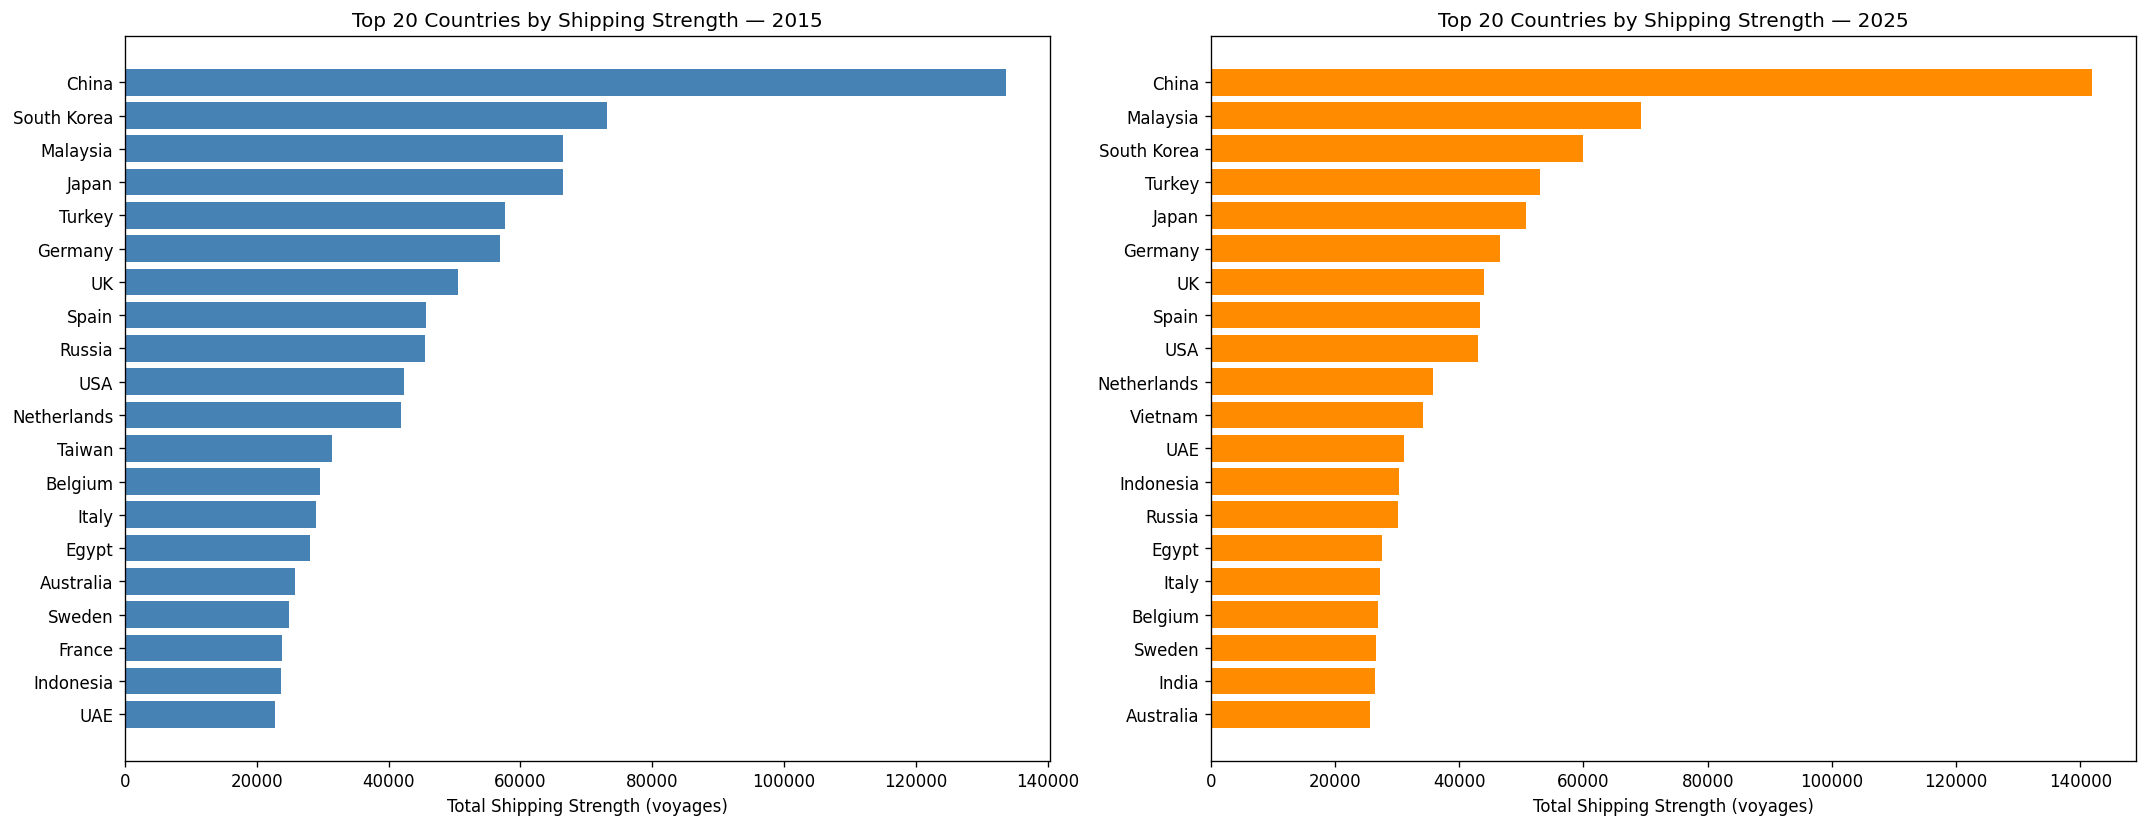

In [ ]:
# Defining the function to create a table for the countries having the highest strength
def top_countries_table(Gd, Gu, year, top_n=20):

    # Calculating the in and out strengths for each node in the directed country network given
    in_s  = dict(Gd.in_degree(weight='weight'))
    out_s = dict(Gd.out_degree(weight='weight'))

    # Calculating the total strength (in + out) for ranking
    total_s = {c: in_s.get(c, 0) + out_s.get(c, 0) for c in Gu.nodes()}

    # Calculating the country-wise degree (number of trading partners) from the given undirected network
    deg   = dict(Gu.degree())

    # Selecting the top_n countries by total strength
    rows = sorted(total_s.items(), key=lambda x: x[1], reverse=True)[:top_n]

    # Creating a dataframe to store the details for the given directed and undirected graphs
    df = pd.DataFrame([
        {'Rank': i+1, 'Country': country_name(c), 'Code': c.upper(),
         'Total Strength': s, 'In-Strength': in_s.get(c, 0),
         'Out-Strength': out_s.get(c, 0), 'Degree': deg.get(c, 0)}
        for i, (c, s) in enumerate(rows)
    ])

    # Printing the table and returning for plotting/saving later
    print(f'\nTop {top_n} countries by shipping strength — {year}')
    print(df.to_string(index=False))
    return df

# Building the top-country tables for both years
df_top_15 = top_countries_table(Gc_d_2015, Gc_u_2015, '2015')
df_top_25 = top_countries_table(Gc_d_2025, Gc_u_2025, '2025')

# Creating side-by-side horizontal bar charts comparing top countries by strength
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Iterating over years and their corresponding node strength and degree data
for ax, df_top, year, color in [
        (axes[0], df_top_15, '2015', 'steelblue'),
        (axes[1], df_top_25, '2025', 'darkorange')]:

    # Plotting the horizontal bar charts for the country-wise strengths
    ax.barh(df_top['Country'][::-1], df_top['Total Strength'][::-1],
            color=color, edgecolor='none')
    ax.set_xlabel('Total Shipping Strength (voyages)')
    ax.set_title(f'Top 20 Countries by Shipping Strength — {year}')

# Saving and showing the figure
plt.tight_layout()
plt.savefig(FIG_DIR + '06_top_countries_strength.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Country Strength & Degree Distribution


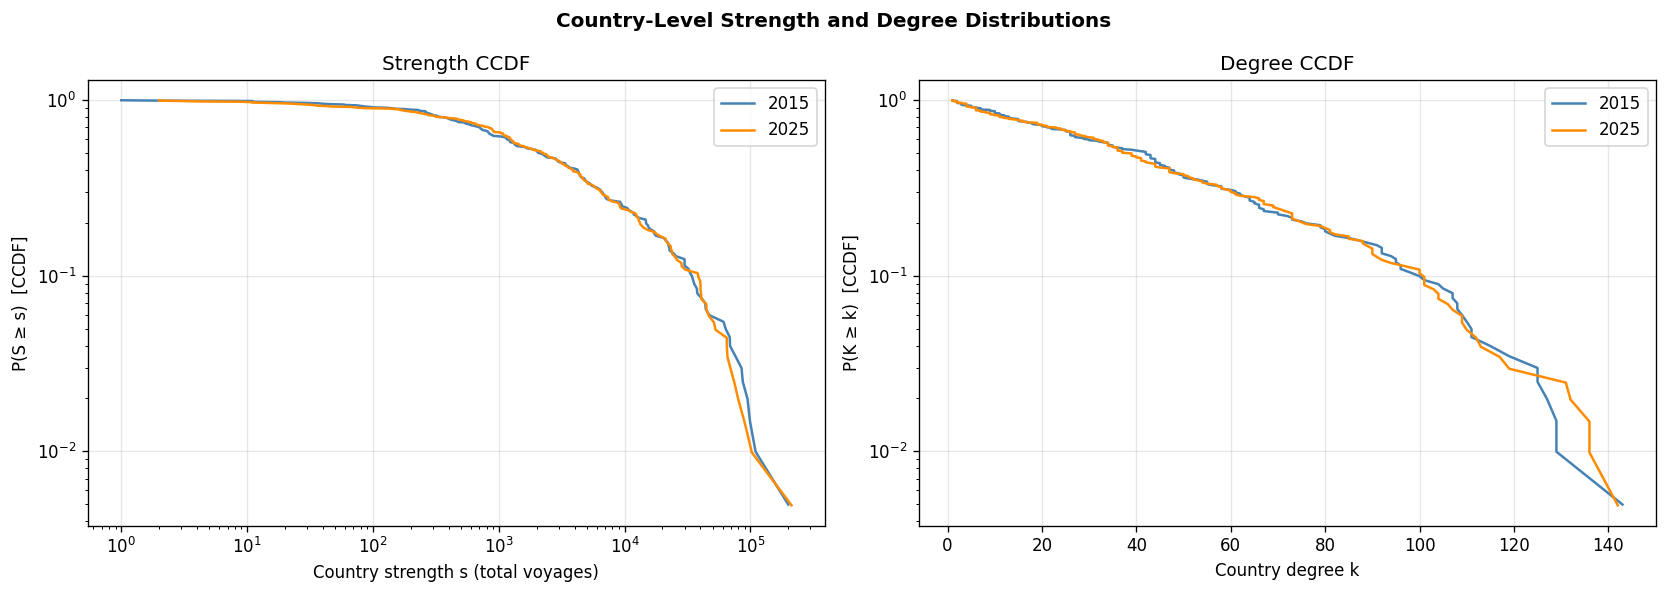

In [ ]:
# Plotting the country-level strength and degree distributions (CCDFs) for 2015 and 2025
# We show complementary cumulative distributions to emphasise heavy tails.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Country-Level Strength and Degree Distributions', fontsize=12, fontweight='bold')

# Iterating over each year and its corresponding weighted graphs
for year, Gu, color in [('2015', Gc_u_2015, 'steelblue'), ('2025', Gc_u_2025, 'darkorange')]:

    # Calculating the strengths and degrees for each node in given graph
    strengths = sorted([d for _, d in Gu.degree(weight='weight')], reverse=True)
    degrees   = sorted([d for _, d in Gu.degree()], reverse=True)

    # CCDF: plot rank / n vs value on log scales to reveal power-law-like tails
    n = len(strengths)
    axes[0].loglog(strengths, np.arange(1, n+1) / n,
                   '-', color=color, lw=1.5, label=year)
    axes[1].semilogy(degrees, np.arange(1, n+1) / n,
                     '-', color=color, lw=1.5, label=year)

# Defining the axis labels, legends and grid for clarity
axes[0].set_xlabel('Country strength s (total voyages)')
axes[0].set_ylabel('P(S ≥ s)  [CCDF]')
axes[0].set_title('Strength CCDF')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Country degree k')
axes[1].set_ylabel('P(K ≥ k)  [CCDF]')
axes[1].set_title('Degree CCDF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Saving and showing the distributions figure
plt.tight_layout()
plt.savefig(FIG_DIR + '06_country_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Temporal Comparison: 2015 vs 2025

Which countries gained or lost shipping importance over the decade?


Countries in both years : 199
New in 2025             : 4  → ['ata', 'blm', 'mda', 'spm']
Gone by 2025            : 2 → ['imn', 'pcn']

Top 10 countries with largest INCREASE in shipping strength:
 Country Code  s_2015  s_2025  pct_change
Cambodia  KHM     324    3175       879.9
  Monaco  MCO      11      88       700.0
     MSR  MSR      59     247       318.6
     SGS  SGS       1       4       300.0
     SHN  SHN      20      67       235.0
     SVK  SVK     262     855       226.3
     TCA  TCA     479    1448       202.3
  Brunei  BRN     412    1225       197.3
     HUN  HUN     179     521       191.1
     AUT  AUT     261     756       189.7

Top 10 countries with largest DECREASE:
  Country Code  s_2015  s_2025  pct_change
      TUV  TUV      60      29       -51.7
      SJM  SJM      74      35       -52.7
      COK  COK      82      33       -59.8
  Ukraine  UKR   22088    7406       -66.5
      KIR  KIR     149      47       -68.5
      ALA  ALA      37       9       -75.7

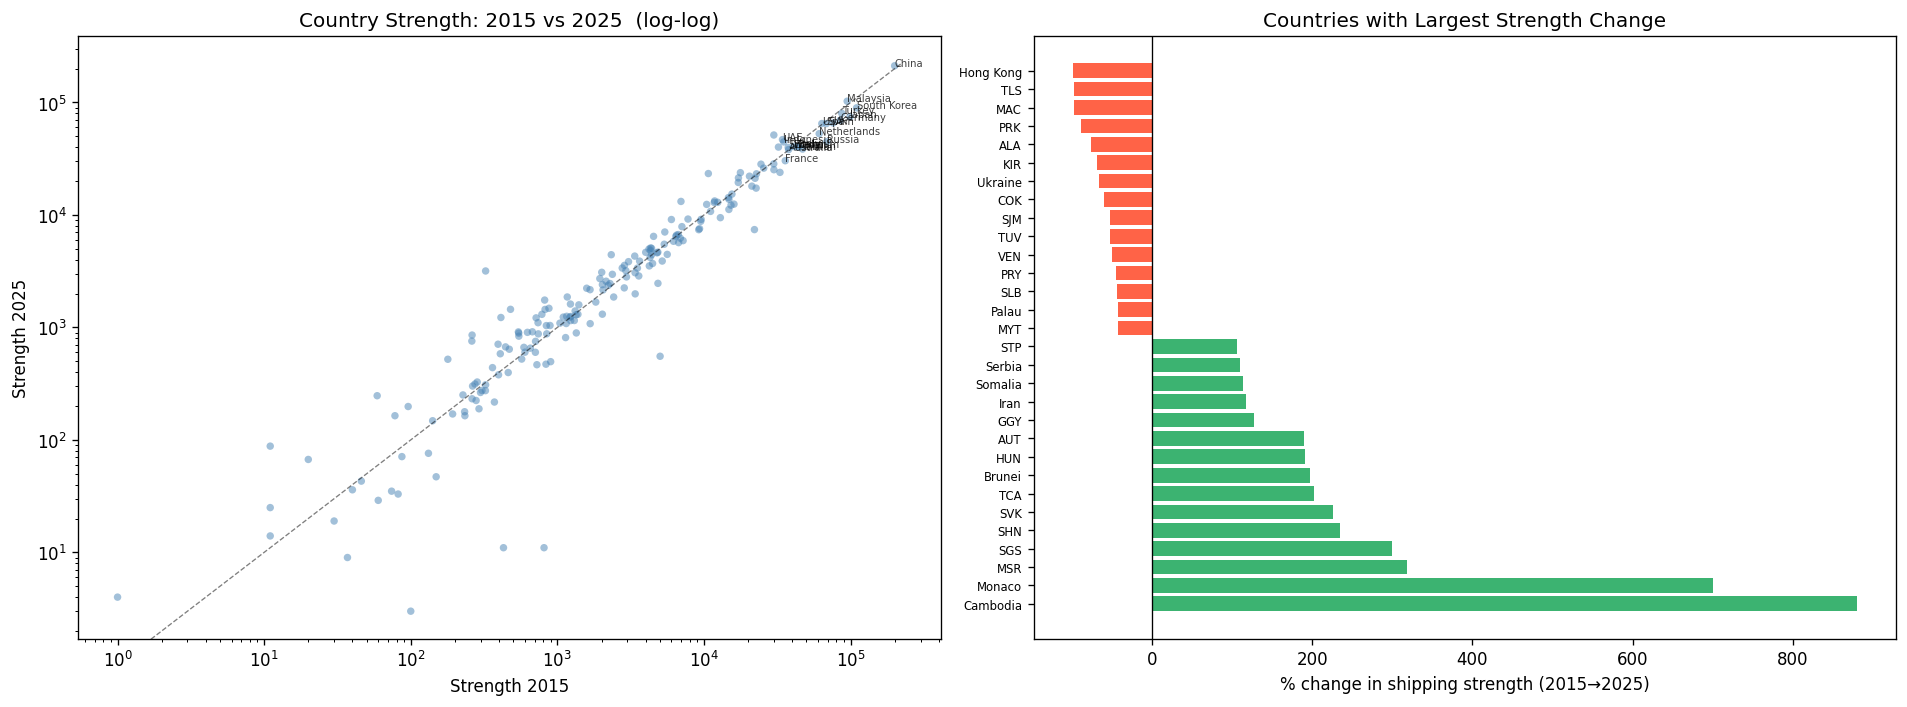

In [ ]:
# Comparing the per-country strength between 2015 and 2025
# Strength is computed on the undirected country network (total voyages per country)
s15 = {c: Gc_u_2015.degree(c, weight='weight') for c in Gc_u_2015.nodes()}
s25 = {c: Gc_u_2025.degree(c, weight='weight') for c in Gc_u_2025.nodes()}

# Identifying the countries present in both years, new in 2025, and lost in 2025
common_c = set(s15) & set(s25)
new_c    = set(s25) - set(s15)
lost_c   = set(s15) - set(s25)

# Printing the stats as computed above about the difference in the countries in the country network between the two years' data
print(f'Countries in both years : {len(common_c)}')
print(f'New in 2025             : {len(new_c)}  → {sorted(new_c)}')
print(f'Gone by 2025            : {len(lost_c)} → {sorted(lost_c)}')

# Computing the percentage change in strength for countries present in both years (ignore zero baseline)
changes = {c: (s25[c] - s15[c]) / s15[c] * 100 for c in common_c if s15[c] > 0}

# Creating a dataframe with the above data for easy manipulation later
df_change = pd.DataFrame([
    {'Country': country_name(c), 'Code': c.upper(),
     's_2015': s15[c], 's_2025': s25[c], 'pct_change': round(changes[c], 1)}
    for c in common_c
]).sort_values('pct_change', ascending=False)

# Printing the top increases/decreases for quick inspection
print('\nTop 10 countries with largest INCREASE in shipping strength:')
print(df_change.head(10).to_string(index=False))
print('\nTop 10 countries with largest DECREASE:')
print(df_change.tail(10).to_string(index=False))

# Plotting the scatter plot of 2015 vs 2025 strength (log-log) and bar chart of percent change
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: each point is a country and diagonal shows no-change
x15 = [s15[c] for c in common_c]
x25 = [s25[c] for c in common_c]
axes[0].scatter(x15, x25, alpha=0.5, s=20, color='steelblue', edgecolors='none')
lim = max(max(x15), max(x25)) * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Strength 2015')
axes[0].set_ylabel('Strength 2025')
axes[0].set_title('Country Strength: 2015 vs 2025  (log-log)')

# Annotating a few top countries for readability (90th percentile by 2015 strength)
for c in list(common_c):
    if s15[c] > np.percentile(list(s15.values()), 90):
        axes[0].annotate(country_name(c), (s15[c], s25[c]), fontsize=6, alpha=0.75)

# Bar plot: percent change for top gainers and losers combined
top_gain = df_change.head(15)
top_loss = df_change.tail(15)
df_bar = pd.concat([top_gain, top_loss])
bar_colors = ['tomato' if v < 0 else 'mediumseagreen' for v in df_bar['pct_change']]
axes[1].barh(df_bar['Country'], df_bar['pct_change'], color=bar_colors, edgecolor='none')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('% change in shipping strength (2015→2025)')
axes[1].set_title('Countries with Largest Strength Change')
axes[1].tick_params(axis='y', labelsize=7)

# Saving and displaying the temporal comparison figure
plt.tight_layout()
plt.savefig(FIG_DIR + '06_country_temporal_change.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Country Flow Balance — Net Importer / Exporter

A country is a **net exporter** if it dispatches more cargo than it receives (out-strength > in-strength),
and a **net importer** in the opposite case.


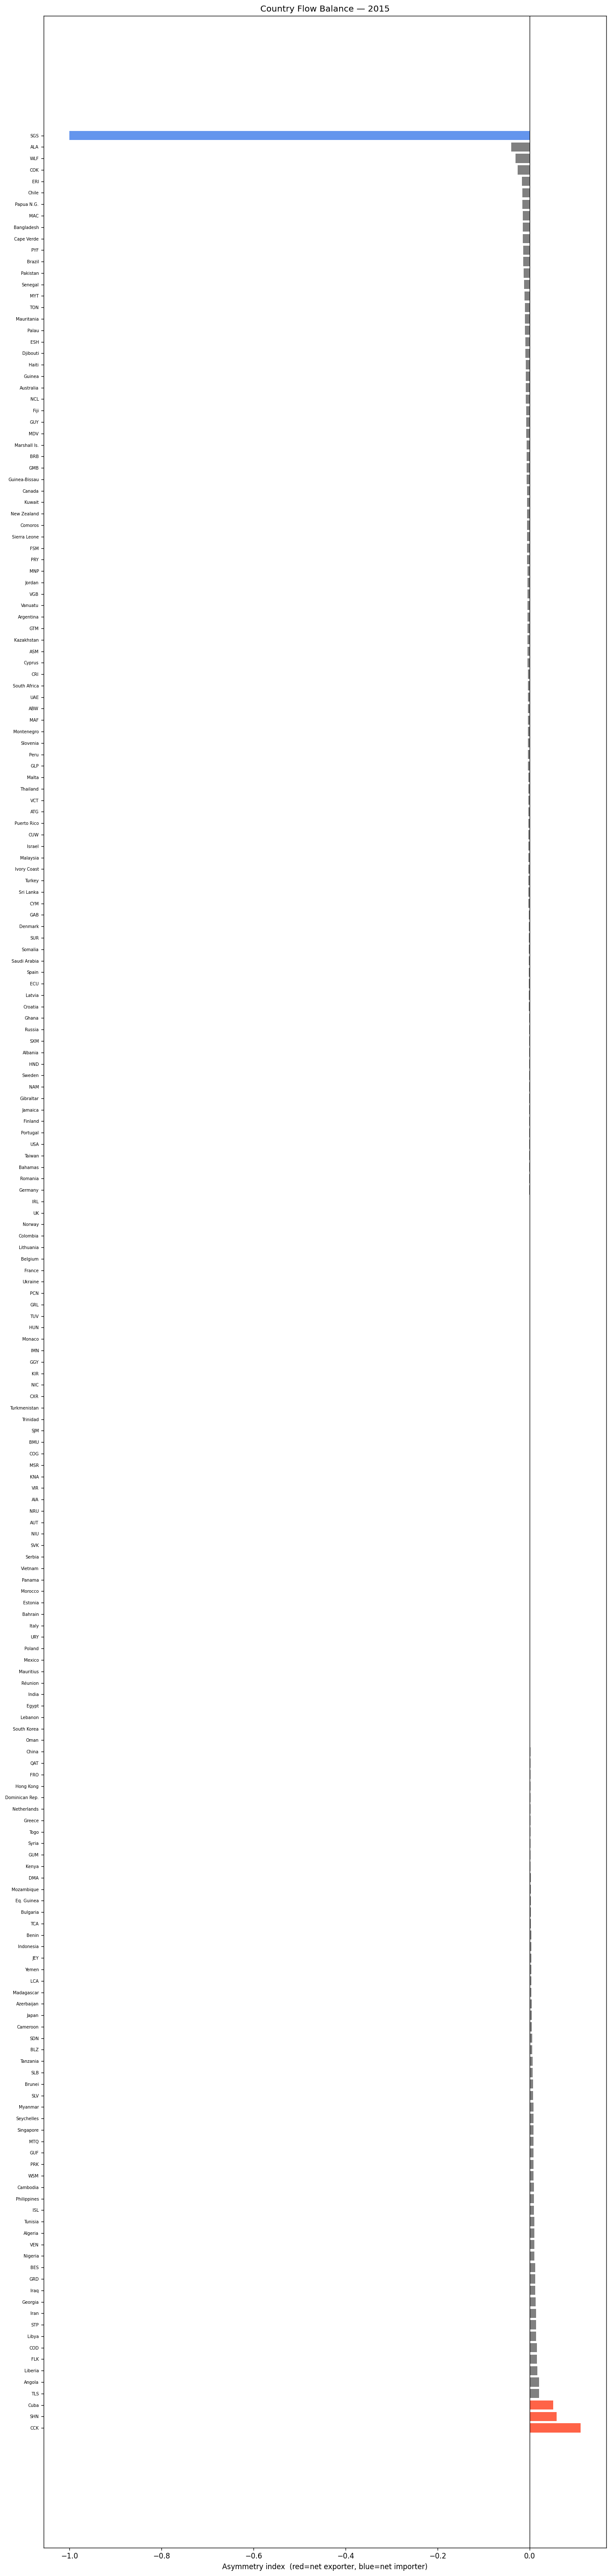


2015 — Top 10 net exporters:
  CCK                   A=+0.111  (out=5, in=4)
  SHN                   A=+0.059  (out=9, in=8)
  Cuba                  A=+0.051  (out=440, in=397)
  TLS                   A=+0.021  (out=148, in=142)
  Angola                A=+0.021  (out=988, in=948)
  Liberia               A=+0.017  (out=272, in=263)
  FLK                   A=+0.016  (out=31, in=30)
  COD                   A=+0.016  (out=188, in=182)
  Libya                 A=+0.014  (out=1,490, in=1,448)
  STP                   A=+0.014  (out=36, in=35)

2015 — Top 10 net importers:
  Cape Verde            A=-0.015  (out=199, in=205)
  Bangladesh            A=-0.015  (out=2,015, in=2,076)
  MAC                   A=-0.015  (out=33, in=34)
  Papua N.G.            A=-0.015  (out=639, in=659)
  Chile                 A=-0.015  (out=2,104, in=2,170)
  ERI                   A=-0.017  (out=87, in=90)
  COK                   A=-0.026  (out=37, in=39)
  WLF                   A=-0.030  (out=16, in=17)
  ALA       

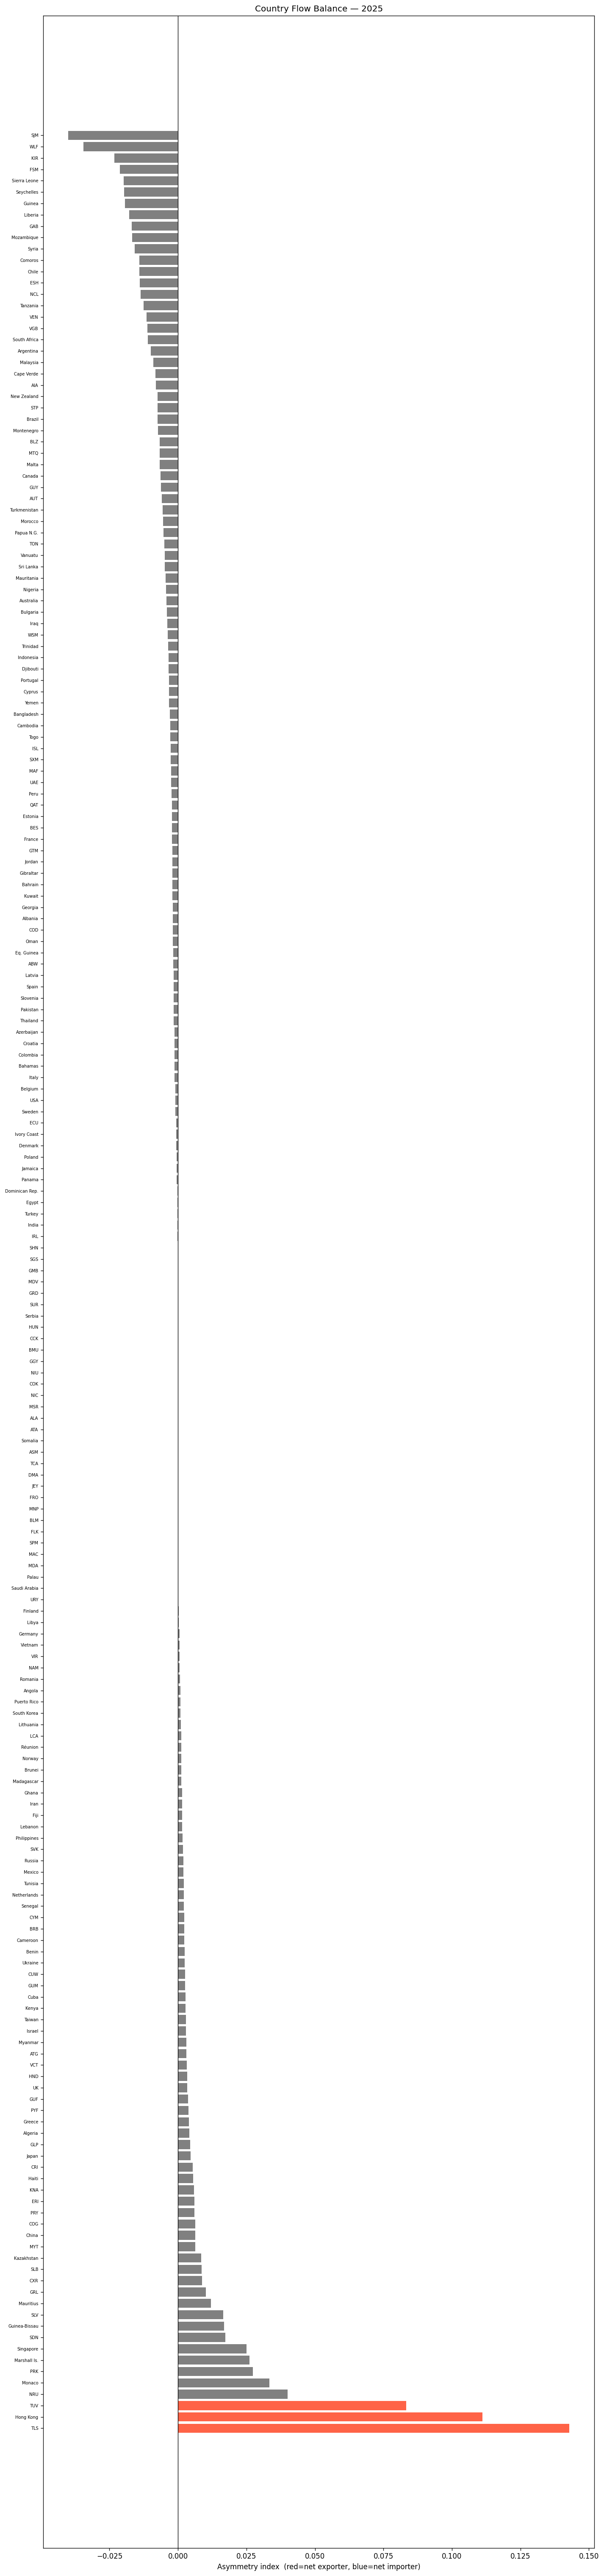


2025 — Top 10 net exporters:
  TLS                   A=+0.143  (out=4, in=3)
  Hong Kong             A=+0.111  (out=5, in=4)
  TUV                   A=+0.083  (out=13, in=11)
  NRU                   A=+0.040  (out=13, in=12)
  Monaco                A=+0.033  (out=31, in=29)
  PRK                   A=+0.027  (out=188, in=178)
  Marshall Is.          A=+0.026  (out=59, in=56)
  Singapore             A=+0.025  (out=8,192, in=7,793)
  SDN                   A=+0.017  (out=675, in=652)
  Guinea-Bissau         A=+0.017  (out=91, in=88)

2025 — Top 10 net importers:
  Mozambique            A=-0.017  (out=1,320, in=1,365)
  GAB                   A=-0.017  (out=465, in=481)
  Liberia               A=-0.018  (out=359, in=372)
  Guinea                A=-0.019  (out=934, in=971)
  Seychelles            A=-0.020  (out=100, in=104)
  Sierra Leone          A=-0.020  (out=346, in=360)
  FSM                   A=-0.021  (out=69, in=72)
  KIR                   A=-0.023  (out=21, in=22)
  WLF             

In [ ]:
# Defining a function to compute and plot the flow balance (net exporter/importer) per country
def country_flow_balance(Gd, year, top_n=20):

    # Calculating the weighted in- and out-strength for each country
    in_s  = dict(Gd.in_degree(weight='weight'))
    out_s = dict(Gd.out_degree(weight='weight'))

    # List to store the asymmetry index for each country in the given graph
    rows = []

    # Calculating the asymmetry index for each country
    for c in Gd.nodes(): # Iterating over each country

        si, so = in_s.get(c, 0), out_s.get(c, 0)
        total  = si + so

        # Asymmetry index ranges from -1 (pure importer) to +1 (pure exporter)
        asym   = (so - si) / total if total > 0 else 0.0
        rows.append({'country': country_name(c), 'code': c.upper(),
                     's_in': si, 's_out': so, 'asymmetry': asym})

    # Creating a dataframe from the above computed data for easier manipulation later
    df = pd.DataFrame(rows).sort_values('asymmetry', ascending=False)

    # Plotting the full ordered list, coloring by exporter/importer threshold for readability
    fig, ax = plt.subplots(figsize=(12, max(6, len(df)*0.25)))

    # Showing all countries sorted by asymmetry
    bar_c = ['tomato' if a > 0.05 else ('cornflowerblue' if a < -0.05 else 'grey')
             for a in df['asymmetry']]
    ax.barh(df['country'], df['asymmetry'], color=bar_c, edgecolor='none')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Asymmetry index  (red=net exporter, blue=net importer)')
    ax.set_title(f'Country Flow Balance — {year}')
    ax.tick_params(axis='y', labelsize=6)
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'06_country_flow_balance_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Printing the top exporters/importers for quick textual summary
    print(f'\n{year} — Top 10 net exporters:')
    for _, r in df.head(10).iterrows():
        print(f'  {r["country"]:20s}  A={r["asymmetry"]:+.3f}  (out={r["s_out"]:,}, in={r["s_in"]:,})')
    print(f'\n{year} — Top 10 net importers:')
    for _, r in df.tail(10).iterrows():
        print(f'  {r["country"]:20s}  A={r["asymmetry"]:+.3f}  (out={r["s_out"]:,}, in={r["s_in"]:,})')
    return df

# Computing flow balance for both years and storing the results
flow_15 = country_flow_balance(Gc_d_2015, '2015')
flow_25 = country_flow_balance(Gc_d_2025, '2025')


## 7. Community Structure at Country Level

Louvain community detection on the **undirected weighted** country network reveals **macro-level trade blocs** —
groups of countries that ship predominantly among themselves.



2015 — Louvain: 8 communities, Q = 0.5656
  Community 1 (48 countries): ABW, AIA, ATG, BES, BLZ, BMU, BRB, Bahamas, CRI, CUW, CYM, Canada, Chile, Colombia, Cuba, DMA, Dominican Rep., ECU, GLP, GRD, GTM, GUF, GUY, HND, Haiti, Jamaica, KNA, LCA, MAF, MSR, MTQ, Mexico, NIC, PCN, PYF, Panama, Peru, Puerto Rico, SLV, SUR, SXM, TCA, Trinidad, USA, VCT, VEN, VGB, VIR
  Community 2 (43 countries): Australia, Bangladesh, Brunei, CCK, CXR, Cambodia, China, Comoros, Fiji, Hong Kong, India, Indonesia, Japan, Kenya, MAC, MDV, MYT, Madagascar, Malaysia, Mauritius, Mozambique, Myanmar, NAM, NCL, NRU, New Zealand, PRK, Pakistan, Papua N.G., Philippines, Réunion, SLB, Seychelles, Singapore, South Africa, South Korea, Sri Lanka, TLS, Taiwan, Tanzania, Thailand, Vanuatu, Vietnam
  Community 3 (40 countries): Albania, Algeria, Azerbaijan, Bulgaria, Cape Verde, Croatia, Cyprus, ESH, Egypt, France, GMB, Georgia, Gibraltar, Greece, Guinea, Guinea-Bissau, Israel, Italy, Kazakhstan, Lebanon, Liberia, Libya, M

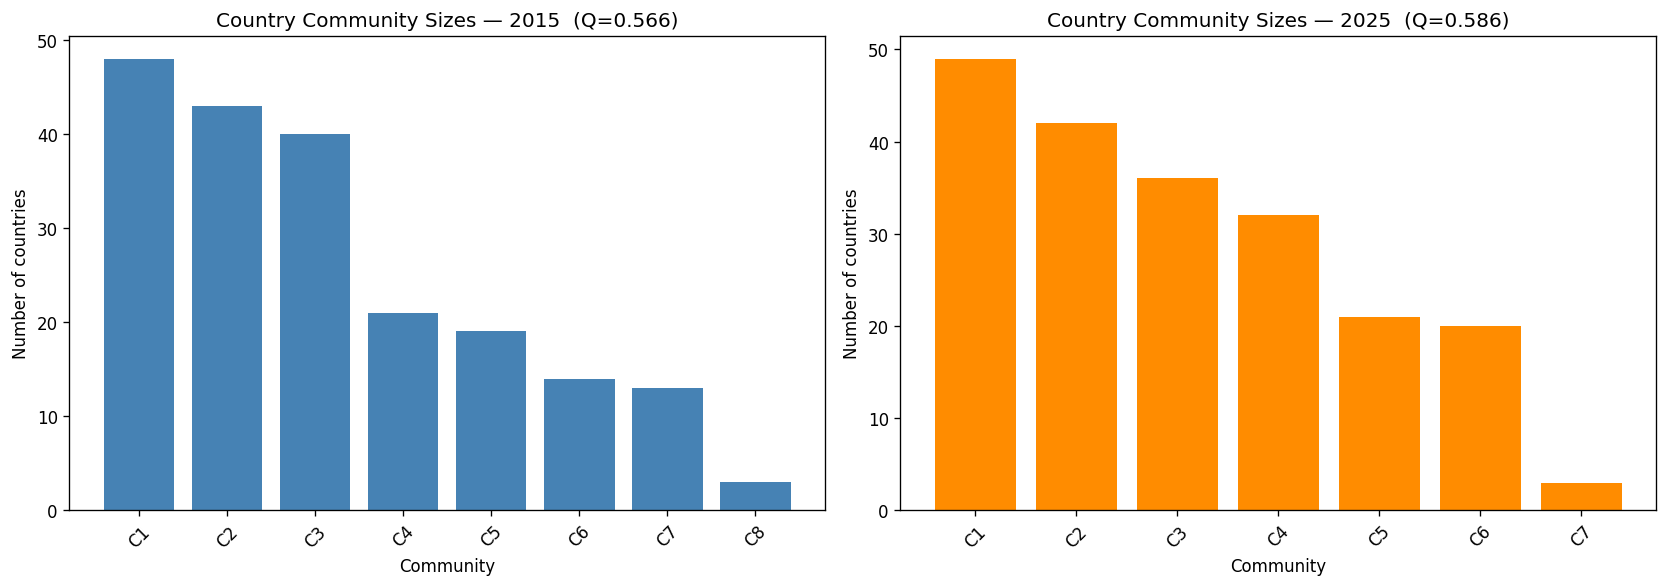

In [ ]:
# Defining a function to detect communities in the undirected weighted country graph given
def detect_country_communities(Gu, label):
    try:
        # Using the built-in NetworkX Louvain implementation (if present)
        comms = list(nx.community.louvain_communities(Gu, weight='weight', seed=42))
        method = 'Louvain'
    except AttributeError:
        # Falling back to the python-louvain package if NetworkX lacks the API
        import community as community_louvain
        part = community_louvain.best_partition(Gu, weight='weight', random_state=42)
        from collections import defaultdict
        d = defaultdict(set)
        for node, cid in part.items():
            d[cid].add(node)
        comms = list(d.values())
        method = 'Louvain (python-louvain)'

    # Computing the modularity to assess community quality
    Q = nx.community.modularity(Gu, comms, weight='weight')
    print(f'\n{label} — {method}: {len(comms)} communities, Q = {Q:.4f}')

    # Printing the largest communities
    comms_sorted = sorted(comms, key=len, reverse=True)
    for i, c in enumerate(comms_sorted[:8]):
        names = ', '.join(sorted(country_name(p) for p in c))
        print(f'  Community {i+1} ({len(c)} countries): {names}')

    return comms_sorted, Q

# Detecting the communities for both years and capturing modularity scores
comms_c_2015, Q_c_2015 = detect_country_communities(Gc_u_2015, '2015')
comms_c_2025, Q_c_2025 = detect_country_communities(Gc_u_2025, '2025')

# Plotting the Community size bar chart which visualise how many countries each community contains
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, comms, year, Q in [(axes[0], comms_c_2015, '2015', Q_c_2015),
                             (axes[1], comms_c_2025, '2025', Q_c_2025)]:
    sizes = [len(c) for c in comms]
    labels = [f'C{i+1}' for i in range(len(sizes))]
    ax.bar(labels, sizes, color='steelblue' if year == '2015' else 'darkorange',
           edgecolor='none')
    ax.set_xlabel('Community')
    ax.set_ylabel('Number of countries')
    ax.set_title(f'Country Community Sizes — {year}  (Q={Q:.3f})')
    ax.tick_params(axis='x', rotation=45)

# Fixing the layout and saving the plot in the given filename, along with showing the plot
plt.tight_layout()
plt.savefig(FIG_DIR + '06_country_communities.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Country Centrality: PageRank and Betweenness

- **PageRank** (directed, weighted): which countries are fed by other major shipping nations?
- **Betweenness centrality**: which countries are the key *relay* nodes on international cargo routes?


Computing PageRank and betweenness centrality for country networks ...

Top 20 countries by PageRank — 2015
 PR Rank     Country Code  PageRank ×10⁻⁴     BC  BC Rank  Degree
       1       China  CHN         589.044 0.0255       12     129
       2    Malaysia  MYS         327.229 0.0288        8     125
       3         USA  USA         312.610 0.0141       40     143
       4 South Korea  KOR         303.338 0.0136       42      92
       5       Japan  JPN         281.746 0.0225       16      95
       6      Turkey  TUR         276.358 0.0195       19     107
       7       Spain  ESP         263.633 0.0037      117     125
       8     Germany  DEU         259.021 0.0075       87     104
       9          UK  GBR         246.337 0.0169       27     111
      10      Russia  RUS         211.651 0.0172       25     119
      11 Netherlands  NLD         196.576 0.0192       21     127
      12       Italy  ITA         159.474 0.0199       18      95
      13         UAE  ARE         

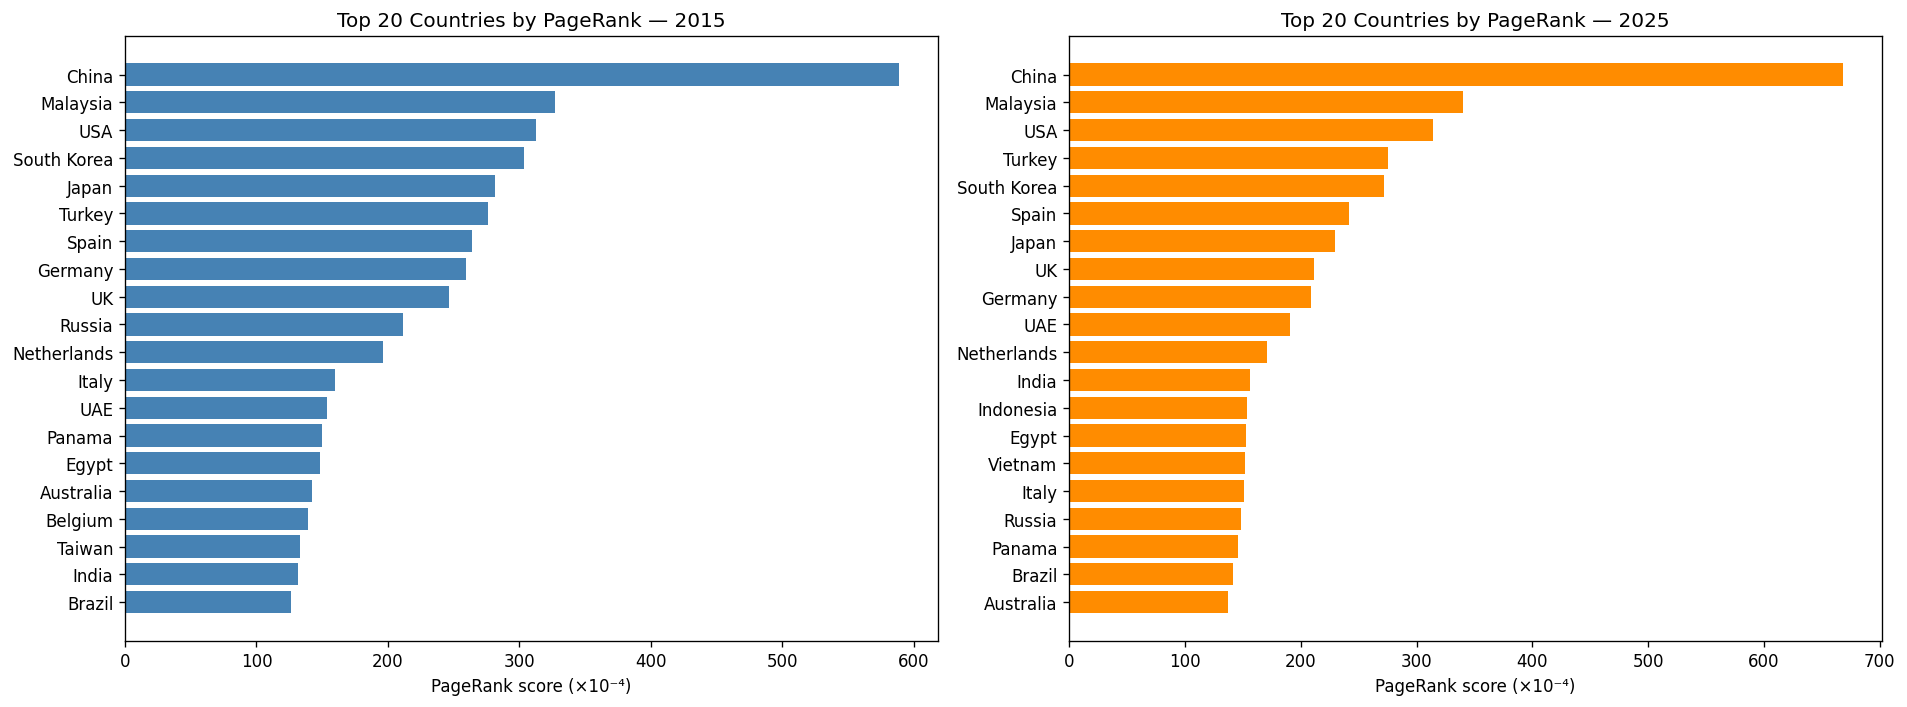

In [ ]:
# Defining the constant to set the threshold for the number of top countries to display
TOP_C = 20

# Computing the centrality measures used to identify influential countries
# Calculating the pagerank on the directed weighted graph which highlights countries receiving traffic
print('Computing PageRank and betweenness centrality for country networks ...')
pr_c_2015 = nx.pagerank(Gc_d_2015, alpha=0.85, weight='weight', max_iter=1000)
pr_c_2025 = nx.pagerank(Gc_d_2025, alpha=0.85, weight='weight', max_iter=1000)

# Calculating the betweenness on the undirected weighted graph which identifies relay countries
bc_c_2015 = nx.betweenness_centrality(Gc_u_2015, normalized=True, weight='weight')
bc_c_2025 = nx.betweenness_centrality(Gc_u_2025, normalized=True, weight='weight')

# Defining a function to create a printable version of the topc countries by PageRank with BC and degree
def centrality_table(pr, bc, Gu, year, top_n=TOP_C):

    # Extracting the Degree for each country in thr given country network
    deg = dict(Gu.degree())

    # List to store the results
    rows = []

    # Ranking countries according to the PageRank in descending order and getting the top_n countries from this list
    pr_sorted = sorted(pr, key=pr.get, reverse=True)[:top_n]

    # Building a rank map for betweenness centrality for cross-comparison
    bc_rank = {c: r+1 for r, c in enumerate(sorted(bc, key=bc.get, reverse=True))}
    for rank, c in enumerate(pr_sorted, 1):
        rows.append({
            'PR Rank': rank, 'Country': country_name(c), 'Code': c.upper(),
            'PageRank ×10⁻⁴': round(pr[c]*1e4, 3),
            'BC': round(bc.get(c, 0), 4),
            'BC Rank': bc_rank.get(c, '—'),
            'Degree': deg.get(c, 0),
        })

    # Saving and showing the above calculated data as a DataFrame
    df = pd.DataFrame(rows)
    print(f'\nTop {top_n} countries by PageRank — {year}')
    print(df.to_string(index=False))

    return df # Returning the dataframe

# Tabulating the centrality for both years
df_cent_15 = centrality_table(pr_c_2015, bc_c_2015, Gc_u_2015, '2015')
df_cent_25 = centrality_table(pr_c_2025, bc_c_2025, Gc_u_2025, '2025')

# Plotting the side-by-side PageRank bar charts for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, df_c, year, color in [
        (axes[0], df_cent_15, '2015', 'steelblue'),
        (axes[1], df_cent_25, '2025', 'darkorange')]:
    ax.barh(df_c['Country'][::-1], df_c['PageRank ×10⁻⁴'][::-1],
            color=color, edgecolor='none')
    ax.set_xlabel('PageRank score (×10⁻⁴)')
    ax.set_title(f'Top {TOP_C} Countries by PageRank — {year}')

# Fixing the layout, saving the generated plot in the specified filename and showing the plot
plt.tight_layout()
plt.savefig(FIG_DIR + '06_country_pagerank.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Country-Level Gini & Trade Concentration


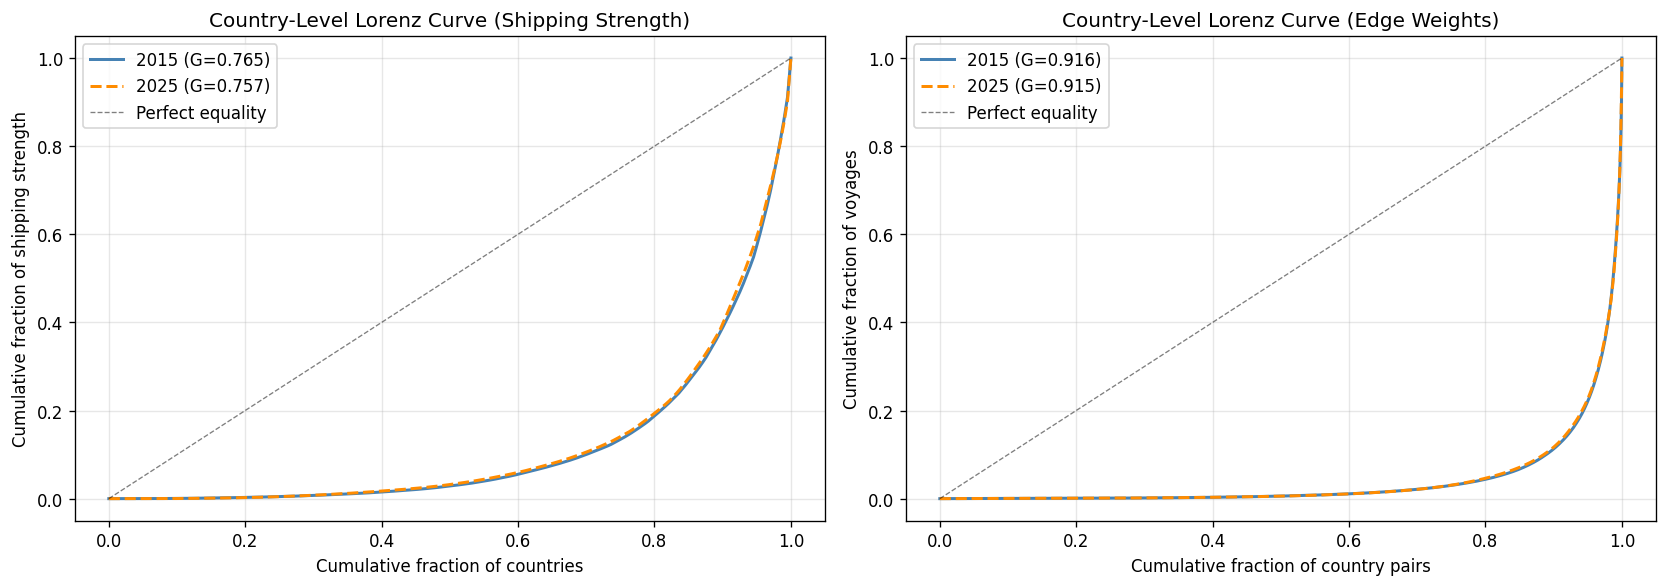

2015 — Gini (strength): 0.7647  |  Gini (edge weights): 0.9162
2025 — Gini (strength): 0.7574  |  Gini (edge weights): 0.9146


In [ ]:
# Defining a function to compute the Gini coefficient for a given array
def gini(arr):
    arr = np.sort(np.asarray(arr, dtype=float))
    arr = arr[arr > 0]
    n = len(arr)
    if n == 0:
        return 0.0
    total = arr.sum()
    rank  = np.arange(1, n + 1)
    return (2 * (rank * arr).sum() - (n + 1) * total) / (n * total)

# Defining a function to compute the lorenz curve cumulative values for plotting
def lorenz(arr):
    arr = np.sort(np.asarray(arr, dtype=float))
    arr = arr[arr > 0]
    cum = np.cumsum(arr)
    return np.insert(cum / cum[-1], 0, 0), np.linspace(0, 1, len(arr) + 1)

# Plotting the two-panel Lorenz curves where left plot is the country strength inequality, and the right plot is edge-weight inequality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Iterating over each year and its corresponding graph data
for year, Gu, color, ls in [('2015', Gc_u_2015, 'steelblue', '-'),
                              ('2025', Gc_u_2025, 'darkorange', '--')]:
    # Calculating the strength values (weighted degree) per country
    s_vals = [Gu.degree(c, weight='weight') for c in Gu.nodes()]
    G = gini(s_vals) # Calculating the gini coefficient for the strength vals for each country
    L_cum, pop_cum = lorenz(s_vals) # Getting the (y, x) coords for plotting the Lorenz curve

    # Plotting the lorenz curve for the strength vals
    axes[0].plot(pop_cum, L_cum, color=color, ls=ls, lw=1.8, label=f'{year} (G={G:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Perfect equality')
axes[0].set_xlabel('Cumulative fraction of countries')
axes[0].set_ylabel('Cumulative fraction of shipping strength')
axes[0].set_title('Country-Level Lorenz Curve (Shipping Strength)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Iterating over each year and its corresponding graph data
for year, Gu, color, ls in [('2015', Gc_u_2015, 'steelblue', '-'),
                              ('2025', Gc_u_2025, 'darkorange', '--')]:
    
    # Calculating the edge values (weighted degree) per country
    w_vals = [d['weight'] for _, _, d in Gu.edges(data=True)]
    G = gini(w_vals) # Calculating the gini coefficient for the weight vals for each country
    L_cum, pop_cum = lorenz(w_vals) # Getting the (y, x) coords for plotting the Lorenz curve

    # Plotting the lorenz curve for the weight vals
    axes[1].plot(pop_cum, L_cum, color=color, ls=ls, lw=1.8, label=f'{year} (G={G:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Perfect equality')
axes[1].set_xlabel('Cumulative fraction of country pairs')
axes[1].set_ylabel('Cumulative fraction of voyages')
axes[1].set_title('Country-Level Lorenz Curve (Edge Weights)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Saving and displaying the inequality plots
plt.tight_layout()
plt.savefig(FIG_DIR + '06_country_lorenz.png', dpi=150, bbox_inches='tight')
plt.show()

# Printing a short numeric summary of Gini coefficients for both years
for year, Gu in [('2015', Gc_u_2015), ('2025', Gc_u_2025)]:
    s_vals = [Gu.degree(c, weight='weight') for c in Gu.nodes()]
    w_vals = [d['weight'] for _, _, d in Gu.edges(data=True)]
    print(f'{year} — Gini (strength): {gini(s_vals):.4f}  |  Gini (edge weights): {gini(w_vals):.4f}')


## 10. Summary Table


In [ ]:
# Defining the rows and the data for the summary table
rows = [
    ('Countries (nodes)',      stats_15['N'],                       stats_25['N'],
     f'{(stats_25["N"]-stats_15["N"])/stats_15["N"]*100:+.1f}%'),
    ('Directed edges',         stats_15['E'],                       stats_25['E'],
     f'{(stats_25["E"]-stats_15["E"])/stats_15["E"]*100:+.1f}%'),
    ('Mean degree ⟨k⟩',        f'{stats_15["k_mean"]:.2f}',         f'{stats_25["k_mean"]:.2f}', '—'),
    ('Reciprocity',            f'{stats_15["reciprocity"]:.4f}',    f'{stats_25["reciprocity"]:.4f}', '—'),
    ('Clustering C',           f'{stats_15["clustering"]:.4f}',     f'{stats_25["clustering"]:.4f}', '—'),
    ('GCC size (%)',           f'{stats_15["gcc_pct"]:.1f}%',       f'{stats_25["gcc_pct"]:.1f}%', '—'),
    ('Communities (Louvain)',  len(comms_c_2015),                   len(comms_c_2025), '—'),
    ('Modularity Q',           f'{Q_c_2015:.4f}',                   f'{Q_c_2025:.4f}', '—'),
    ('Top country (strength)', country_name(df_top_15.iloc[0]["Code"].lower()),
                               country_name(df_top_25.iloc[0]["Code"].lower()), '—'),
]

# Coverting the above defined summary table into a dataframe
df_summary = pd.DataFrame(rows, columns=['Metric', '2015', '2025', '% Change / Note'])

# Printing the above defined summary table
print()
print('=' * 72)
print('  GCSN COUNTRY-LEVEL NETWORK — SUMMARY TABLE')
print('=' * 72)
print(df_summary.to_string(index=False))
print('=' * 72)

# Saving the above defined summary table as a csv file
df_summary.to_csv('../Figures/06_country_summary.csv', index=False)
print('\nSummary saved → ../Figures/06_country_summary.csv')



  GCSN COUNTRY-LEVEL NETWORK — SUMMARY TABLE
                Metric   2015   2025 % Change / Note
     Countries (nodes)    201    203           +1.0%
        Directed edges   7417   7431           +0.2%
       Mean degree ⟨k⟩  45.68  45.43               —
           Reciprocity 0.7620 0.7590               —
          Clustering C 0.7033 0.7067               —
          GCC size (%) 100.0% 100.0%               —
 Communities (Louvain)      8      7               —
          Modularity Q 0.5656 0.5861               —
Top country (strength)  China  China               —

Summary saved → ../Figures/06_country_summary.csv
